In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('DailyDelhiClimateTrain.csv')

In [3]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [4]:
df['date'] = pd.to_datetime(df['date'])

In [5]:
df = df.sort_values('date')

In [6]:
df

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...,...
1457,2016-12-28,17.217391,68.043478,3.547826,1015.565217
1458,2016-12-29,15.238095,87.857143,6.000000,1016.904762
1459,2016-12-30,14.095238,89.666667,6.266667,1017.904762
1460,2016-12-31,15.052632,87.000000,7.325000,1016.100000


In [7]:
data = df[['meantemp', 'humidity', 'wind_speed', 'meanpressure']]

In [8]:
scaler=MinMaxScaler()

In [9]:
scaled_data=scaler.fit_transform(data)

In [10]:
scaled_data

array([[0.12227074, 0.8209571 , 0.        , 0.13260331],
       [0.04279476, 0.90759076, 0.07058266, 0.132881  ],
       [0.0356623 , 0.84983498, 0.10974262, 0.13299381],
       ...,
       [0.24745269, 0.88063806, 0.14842886, 0.13289464],
       [0.276718  , 0.84983498, 0.17349597, 0.13265971],
       [0.12227074, 1.        , 0.        , 0.1326467 ]])

In [11]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][0])  # predict meantemp
    return np.array(X), np.array(y)

seq_length = 30  # use last 30 days
X, y = create_sequences(scaled_data, seq_length)

In [12]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [13]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_length, 4)),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.1296 - val_loss: 0.0054
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0060 - val_loss: 0.0053
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0057 - val_loss: 0.0052
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0049 - val_loss: 0.0049
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0046 - val_loss: 0.0051
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0045 - val_loss: 0.0049
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0047 - val_loss: 0.0048
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0048 - val_loss: 0.0043
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0045 - val_loss: 0.0048
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0044 - val_loss: 0.0042
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0040 - val_loss: 0.0043
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0

In [15]:
predictions = model.predict(X_test)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


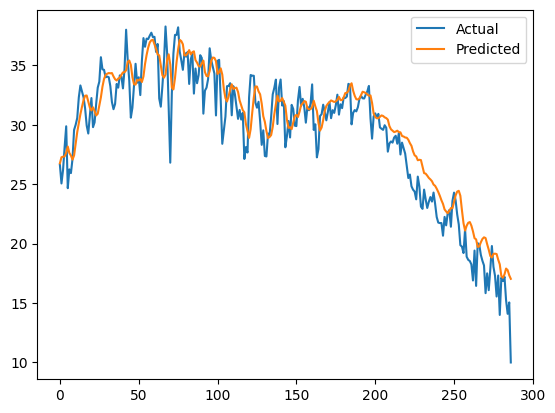

In [16]:
temp_scaler = MinMaxScaler()
temp_scaler.fit(data[['meantemp']])

pred_actual = temp_scaler.inverse_transform(predictions)
y_actual = temp_scaler.inverse_transform(y_test.reshape(-1,1))

# -----------------------------
# 8. Plot
# -----------------------------
plt.plot(y_actual, label="Actual")
plt.plot(pred_actual, label="Predicted")
plt.legend()
plt.show()